In [4]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [5]:
#https://archive.ics.uci.edu/dataset/186/wine+quality

In [6]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [7]:
# 1
# 학습용 테스트용 데이터 분류
# 학습
# 평가

# 2
# 각종 시각화를 통해 컬럼의 특성을 파악
# 학습용 컬럼을 선정
# 전처리
# 학습
# 평가 .score -> accuracy

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y.quality,test_size=0.2,random_state=42,stratify=y)
print( len(x_train), len(y_train)  )

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn.fit(x_train, y_train)
score = knn.score(x_test,y_test)
print(f'정확도 Accuracy :{score}')

from sklearn.metrics import classification_report
y_pred = knn.predict(x_test)
print(classification_report(y_pred, y_test))

5197 5197
정확도 Accuracy :0.48615384615384616
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.07      0.16      0.10        19
           5       0.54      0.46      0.50       502
           6       0.58      0.53      0.55       613
           7       0.29      0.42      0.34       151
           8       0.15      0.43      0.23        14
           9       0.00      0.00      0.00         0

    accuracy                           0.49      1300
   macro avg       0.23      0.29      0.25      1300
weighted avg       0.52      0.49      0.50      1300



c:\Users\sally\SKNPYWORKSPACE\streamlit\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sally\SKNPYWORKSPACE\streamlit\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sally\SKNPYWORKSPACE\streamlit\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [9]:
# 클래스 불균형 문제 해결
y.value_counts()

quality
6          2836
5          2138
7          1079
4           216
8           193
3            30
9             5
Name: count, dtype: int64

original shape Counter({np.int64(0): 947, np.int64(1): 53})
resampled shape Counter({np.int64(0): 947, np.int64(1): 947})


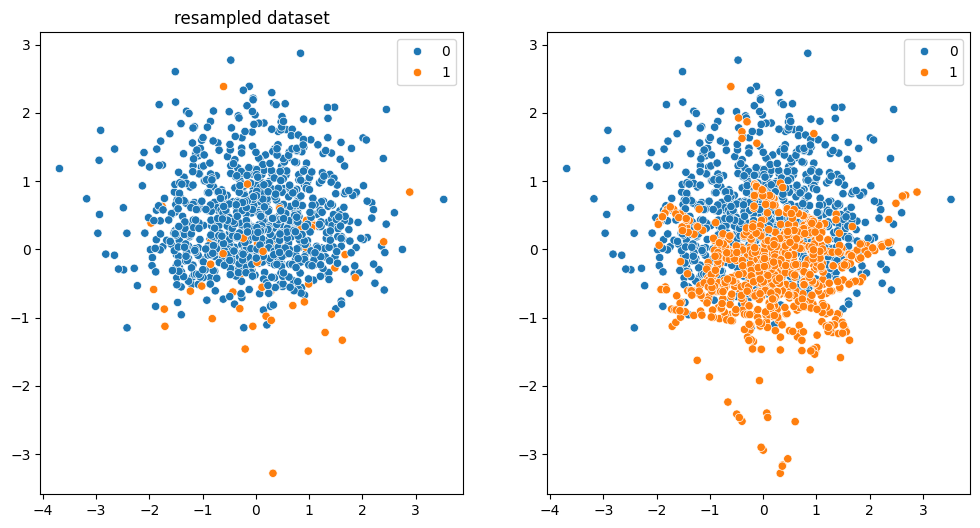

In [10]:
# 오버샘플링 : 정보손실 없이 소수클래스의 특징을 강화 - 데이터증강
# SMOTE Synthtic Ninority Over-sampling Technique
# 비슷한 데이터들 사이에 새로운 데이터를 생성 - 기존 데이터의 정보를  활용
from sklearn.datasets import make_classification
from collections import Counter
X, y = make_classification(n_samples=1000, n_classes=2,random_state=42,weights=[0.95,0.05])
print(f'original shape {Counter(y)}')
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X,y)
print(f'resampled shape {Counter(y_resampled)}')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
fig,ax = plt.subplots(1,2, figsize=(12,6))

sns.scatterplot(x = X[:,0], y=X[:,1],hue=y,ax=ax[0])
ax[0].set_title('original dataset')

sns.scatterplot(x = X_resampled[:,0], y=X_resampled[:,1],hue=y_resampled,ax=ax[1])
ax[0].set_title('resampled dataset')

plt.show()

In [11]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
y = y.to_numpy()
print(Counter(y))

# 데이터 증강
smote = SMOTE(random_state=42,k_neighbors=4)
X, y = smote.fit_resample(X,y)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42
                                                  ,stratify=y)

Counter( y_train)
# print( len(x_train), len(y_train)  )

# from sklearn.neighbors import KNeighborsClassifier
# knn = KNeighborsClassifier()

# knn.fit(x_train, y_train)
# score = knn.score(x_test,y_test)
# print(f'정확도 Accuracy :{score}')

# from sklearn.metrics import classification_report
# y_pred = knn.predict(x_test)
# print(classification_report(y_pred, y_test))

TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
y_train